<div class="alert alert-info" style="background-color:#001b79; color:white; padding:0px 10px; border-radius:5px;"><h2 style='margin:10px 5px'>K MEAN CLUSTER </h2>
</div>

<div class="alert alert-info" style="background-color:#001b32; color:white; padding:0px 10px; border-radius:5px;"><h2 style='margin:10px 5px'>Problem  Statement </h2>
</div>

> We have Movie metadata, cluster these movie based on first two columns of facebook likes 
- 1) director_facebook_likes 
- 2) actor_3_facebook_likes

##  1. Import all Librariy

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from copy import deepcopy

In [3]:
data = pd.read_csv(r'..\Dataset\movie_metadata1.csv')
data.head()

,color,director_name,num_critic_for_reviews,duration,director_facebook_likes,actor_3_facebook_likes,actor_2_name,actor_1_facebook_likes,gross,genres,...,num_user_for_reviews,language,country,content_rating,budget,title_year,actor_2_facebook_likes,imdb_score,aspect_ratio,movie_facebook_likes
0,Color,James Cameron,723,178,0,855,Joel David Moore,1000,760505847,Action|Adventure|Fantasy|Sci-Fi,...,3054,English,USA,PG-13,237000000,2009,936,7.9,1.78,33000
1,Color,Gore Verbinski,302,169,563,1000,Orlando Bloom,40000,309404152,Action|Adventure|Fantasy,...,1238,English,USA,PG-13,300000000,2007,5000,7.1,2.35,0
2,Color,Sam Mendes,602,148,0,161,Rory Kinnear,11000,200074175,Action|Adventure|Thriller,...,994,English,UK,PG-13,245000000,2015,393,6.8,2.35,85000
3,Color,Christopher Nolan,813,164,22000,23000,Christian Bale,27000,448130642,Action|Thriller,...,2701,English,USA,PG-13,250000000,2012,23000,8.5,2.35,164000
4,49,Doug Walker,49,49,131,49,Rob Walker,131,49,Documentary,...,49,49,49,49,49,49,12,7.1,49.00,0


## 2. Data Exploration

In [4]:
data.shape

(5043, 28)

In [5]:
# cluster these movie based on first two columns of facebook likes
f1 = data['director_facebook_likes'].values
f2 = data['actor_3_facebook_likes'].values

# Make this as 1 array 0f 2 values i each rows X*2 array
X = np.array(list(zip(f1,f2)))
X

array([[   0,  855],
       [ 563, 1000],
       [   0,  161],
       ...,
       [   0,    0],
       [   0,  489],
       [  16,   16]], dtype=int64)

In [6]:
print(X)
print("\n", type(X))
print("\n Shape of array: " , X.shape)
print("\n 1st item: " , X[0])
print("\n Length:" , len(X))
print("\n max:" , np.max(X))

[[   0  855]
 [ 563 1000]
 [   0  161]
 ...
 [   0    0]
 [   0  489]
 [  16   16]]

 <class 'numpy.ndarray'>

 Shape of array:  (5043, 2)

 1st item:  [  0 855]

 Length: 5043

 max: 23000


### 2.1 Here Scatter plots will plot each of movie in 2 D space, but not clustered or grouped. In further steps we will do by Kmean clustering

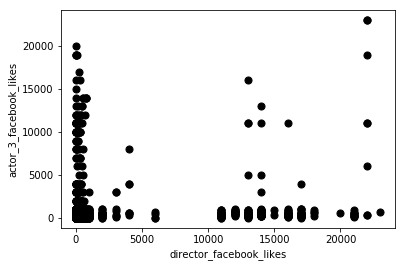

In [7]:
# Here
plt.scatter(f1,f2, c='black', s=50)
plt.xlabel("director_facebook_likes")
plt.ylabel("actor_3_facebook_likes")
plt.show()

## 3. Building Machine Learning KMean Cluster

### 3.1 EUCLEDIAN DISTANCE CALCULATOR

- Here centrod calculation done manually by iteration process, not used Elbow Method to identify K value

In [10]:
# eucledian distance calculator
def dist(a,b,ax=1):
    return np.linalg.norm(a-b, axis=ax)

# number of clusters 
k = 5

# X co-ordinated for random centroids
C_x = np.random.randint(0, np.max(X)-20, size=k)

# y co-ordinated for random centroids
C_y = np.random.randint(0, np.max(X)-20, size=k)

C = np.array(list(zip(C_x, C_y)), dtype=np.float32)
print("Centrod values are :\n", C)

Centrod values are :
 [[20216. 18463.]
 [20768.  4416.]
 [19285.  4226.]
 [11218.   195.]
 [ 3036.  8930.]]


#### 3.1.1 Centrod plotted with Inputs

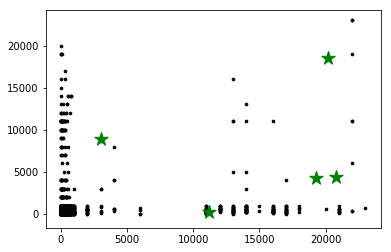

In [11]:
# plotting centroids along with input data
plt.scatter(f1, f2, c='#050505', s=7)
plt.scatter(C_x, C_y, marker='*', s=200, c='g')
plt.show()

### 3.2 Final Centroid and Clustering
    - Here Centroids are recentered and calculated eroors iteratively. This done till it reaches to 0 errors


In [13]:
# To store the value of centroids when it updates
C_old = np.zeros(C.shape)
# Cluster Lables(0, 1, 2)
clusters = np.zeros(len(X))  # This is rowcount of input value. i.e 0,1,2 ...5042
# Error func. - Distance between new centroids and old centroids
error = dist(C, C_old, None)
# Loop will run till the error becomes zero
while error != 0:
    # Assigning each value to its closest cluster
    #Here iteration will be 5043 times
    for i in range(len(X)):
        #Here it gives for each (x,y) pair in X[i] it calculate distance with all 5 Centroid(X,Y) and shows result in np.array
        #Ex Result of distances: [22254.69674935 10273.59879958   459.92315621 12492.86781024  17623.11464523]
        distances = dist(X[i], C)
        #print(X[i])
        #print(C)
        #print(distances)
        
        #Returns the indices of the minimum values along an axis.
        #For above distances 2 will be returned to cluster
        cluster = np.argmin(distances)
        #print(cluster)
        
        clusters[i] = cluster
        #print(clusters)
        
    # Storing the old centroid values
    C_old = deepcopy(C)
    # Finding the new centroids by taking the average value
    #Here iteration will be 5 times
    for i in range(k):
        points = [X[j] for j in range(len(X)) if clusters[j] == i]
        #print(points)
        C[i] = np.mean(points, axis=0)
        #print(C[i])
    error = dist(C, C_old, None)



## 4. Model Evaluation with Visualization

Text(0, 0.5, 'Actor Facebook likes')

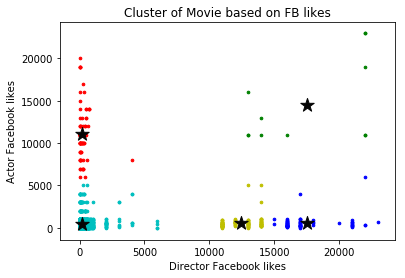

In [15]:
colors = ['r', 'g', 'b', 'y', 'c', 'm']
fig, ax = plt.subplots()
for i in range(k):  # Here k=5 hardcoded earlier
        points = np.array([X[j] for j in range(len(X)) if clusters[j] == i])
        ax.scatter(points[:, 0], points[:, 1], s=7, c=colors[i])
ax.scatter(C[:, 0], C[:, 1], marker='*', s=200, c='#050505')
plt.title("Cluster of Movie based on FB likes")
plt.xlabel("Director Facebook likes")
plt.ylabel("Actor Facebook likes")

## 5. Conclusion

- By seeing cluster, we can decide business underanding of each movies. Movie vs director combination, How those are good and bad